# Bigram Language Model

## Reading in Data and EDA

In [1]:
import numpy as np

In [2]:
with open('names.txt', 'r') as f:
    names = f.readlines()

In [3]:
names[0][0:-1]

'emma'

In [4]:
names = [name[0:-1] for name in names]

In [30]:
# open('names.txt', 'r').read().splitlines()

In [5]:
# shortest name
np.argmin([len(name) for name in names])

np.int64(3654)

In [6]:
names[3654]

'an'

In [7]:
np.argmax([len(name) for name in names])

np.int64(31441)

In [8]:
names[31441]

'muhammadibrahim'

## Bigram Model
only works on 2 chars at a time - loos at a char, then predicts the most likely next char - then the window of size 2 slides to the right

In [9]:
for name in names:
    for ch1, ch2 in zip(name, name[1:]):
        print(ch1, ch2)
    break

e m
m m
m a


In [10]:
for name in names[:3]:
    chs = ['<S>'] + list(name) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [11]:
bigrams = []
for name in names:
    chs = ['<S>'] + list(name) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigrams.append((ch1, ch2))

In [12]:
len(bigrams)

228145

In [13]:
bigrams[:10]

[('<S>', 'e'),
 ('e', 'm'),
 ('m', 'm'),
 ('m', 'a'),
 ('a', '<E>'),
 ('<S>', 'o'),
 ('o', 'l'),
 ('l', 'i'),
 ('i', 'v'),
 ('v', 'i')]

In [14]:
len(set(bigrams))

626

In [15]:
set(bigrams)

{('<S>', 'a'),
 ('<S>', 'b'),
 ('<S>', 'c'),
 ('<S>', 'd'),
 ('<S>', 'e'),
 ('<S>', 'f'),
 ('<S>', 'g'),
 ('<S>', 'h'),
 ('<S>', 'i'),
 ('<S>', 'j'),
 ('<S>', 'k'),
 ('<S>', 'l'),
 ('<S>', 'm'),
 ('<S>', 'n'),
 ('<S>', 'o'),
 ('<S>', 'p'),
 ('<S>', 'q'),
 ('<S>', 'r'),
 ('<S>', 's'),
 ('<S>', 't'),
 ('<S>', 'u'),
 ('<S>', 'v'),
 ('<S>', 'w'),
 ('<S>', 'x'),
 ('<S>', 'y'),
 ('<S>', 'z'),
 ('a', '<E>'),
 ('a', 'a'),
 ('a', 'b'),
 ('a', 'c'),
 ('a', 'd'),
 ('a', 'e'),
 ('a', 'f'),
 ('a', 'g'),
 ('a', 'h'),
 ('a', 'i'),
 ('a', 'j'),
 ('a', 'k'),
 ('a', 'l'),
 ('a', 'm'),
 ('a', 'n'),
 ('a', 'o'),
 ('a', 'p'),
 ('a', 'q'),
 ('a', 'r'),
 ('a', 's'),
 ('a', 't'),
 ('a', 'u'),
 ('a', 'v'),
 ('a', 'w'),
 ('a', 'x'),
 ('a', 'y'),
 ('a', 'z'),
 ('b', '<E>'),
 ('b', 'a'),
 ('b', 'b'),
 ('b', 'c'),
 ('b', 'd'),
 ('b', 'e'),
 ('b', 'h'),
 ('b', 'i'),
 ('b', 'j'),
 ('b', 'l'),
 ('b', 'n'),
 ('b', 'o'),
 ('b', 'r'),
 ('b', 's'),
 ('b', 't'),
 ('b', 'u'),
 ('b', 'y'),
 ('c', '<E>'),
 ('c', 'a'),
 ('c',

In [16]:
from collections import Counter
b = Counter(bigrams) # bigrams is a list of tuples

In [17]:
b

Counter({('n', '<E>'): 6763,
         ('a', '<E>'): 6640,
         ('a', 'n'): 5438,
         ('<S>', 'a'): 4410,
         ('e', '<E>'): 3983,
         ('a', 'r'): 3264,
         ('e', 'l'): 3248,
         ('r', 'i'): 3033,
         ('n', 'a'): 2977,
         ('<S>', 'k'): 2963,
         ('l', 'e'): 2921,
         ('e', 'n'): 2675,
         ('l', 'a'): 2623,
         ('m', 'a'): 2590,
         ('<S>', 'm'): 2538,
         ('a', 'l'): 2528,
         ('i', '<E>'): 2489,
         ('l', 'i'): 2480,
         ('i', 'a'): 2445,
         ('<S>', 'j'): 2422,
         ('o', 'n'): 2411,
         ('h', '<E>'): 2409,
         ('r', 'a'): 2356,
         ('a', 'h'): 2332,
         ('h', 'a'): 2244,
         ('y', 'a'): 2143,
         ('i', 'n'): 2126,
         ('<S>', 's'): 2055,
         ('a', 'y'): 2050,
         ('y', '<E>'): 2007,
         ('e', 'r'): 1958,
         ('n', 'n'): 1906,
         ('y', 'n'): 1826,
         ('k', 'a'): 1731,
         ('n', 'i'): 1725,
         ('r', 'e'): 1697,
      

In [18]:
b.most_common(3)

[(('n', '<E>'), 6763), (('a', '<E>'), 6640), (('a', 'n'), 5438)]

In [19]:
bigrams_dict = dict(b)
bigrams_dict

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [108]:
bigrams_dict.items()

dict_items([(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 18

In [ ]:
# # create d dict to track the count of the bigrams
# b = {} # key: is the tuple of bigrams, value is count
# for name in names:
#     chs = ['<S>'] + list(name) + ['<E>']
#     for ch1, ch2 in zip(chs, chs[1:]):
#       bigrams_t = (ch1, ch2)
#       b[bigrams_t] = b.get(bigrams_t, 0) + 1 

In [ ]:
# sorted(b.items(), key=lambda kv: kv[1], reverse=True)

## Converting data into torch.tensor

In [26]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
device = torch.device('mps')
device

device(type='mps')

In [28]:
N = torch.zeros((28, 28), dtype=torch.int32)
N.shape

torch.Size([28, 28])

In [20]:
# create a mapping from char to int
vocab = sorted(list(set(''.join(names))))
vocab = vocab + ['<S>', '<E>']
vocab

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '<S>',
 '<E>']

In [21]:
char2idx = {char: i for i, char in enumerate(vocab)}
char2idx

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [22]:
idx2char = {i: char for i, char in enumerate(vocab)}
idx2char

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '<S>',
 27: '<E>'}

In [29]:
# so now we wanna populate the N tensor with the counts
for name in names:
    chs = ['<S>'] + list(name) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = char2idx[ch1]
        idx2 = char2idx[ch2]
        N[idx1, idx2] += 1 # because N tesnor is init at 0

In [30]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

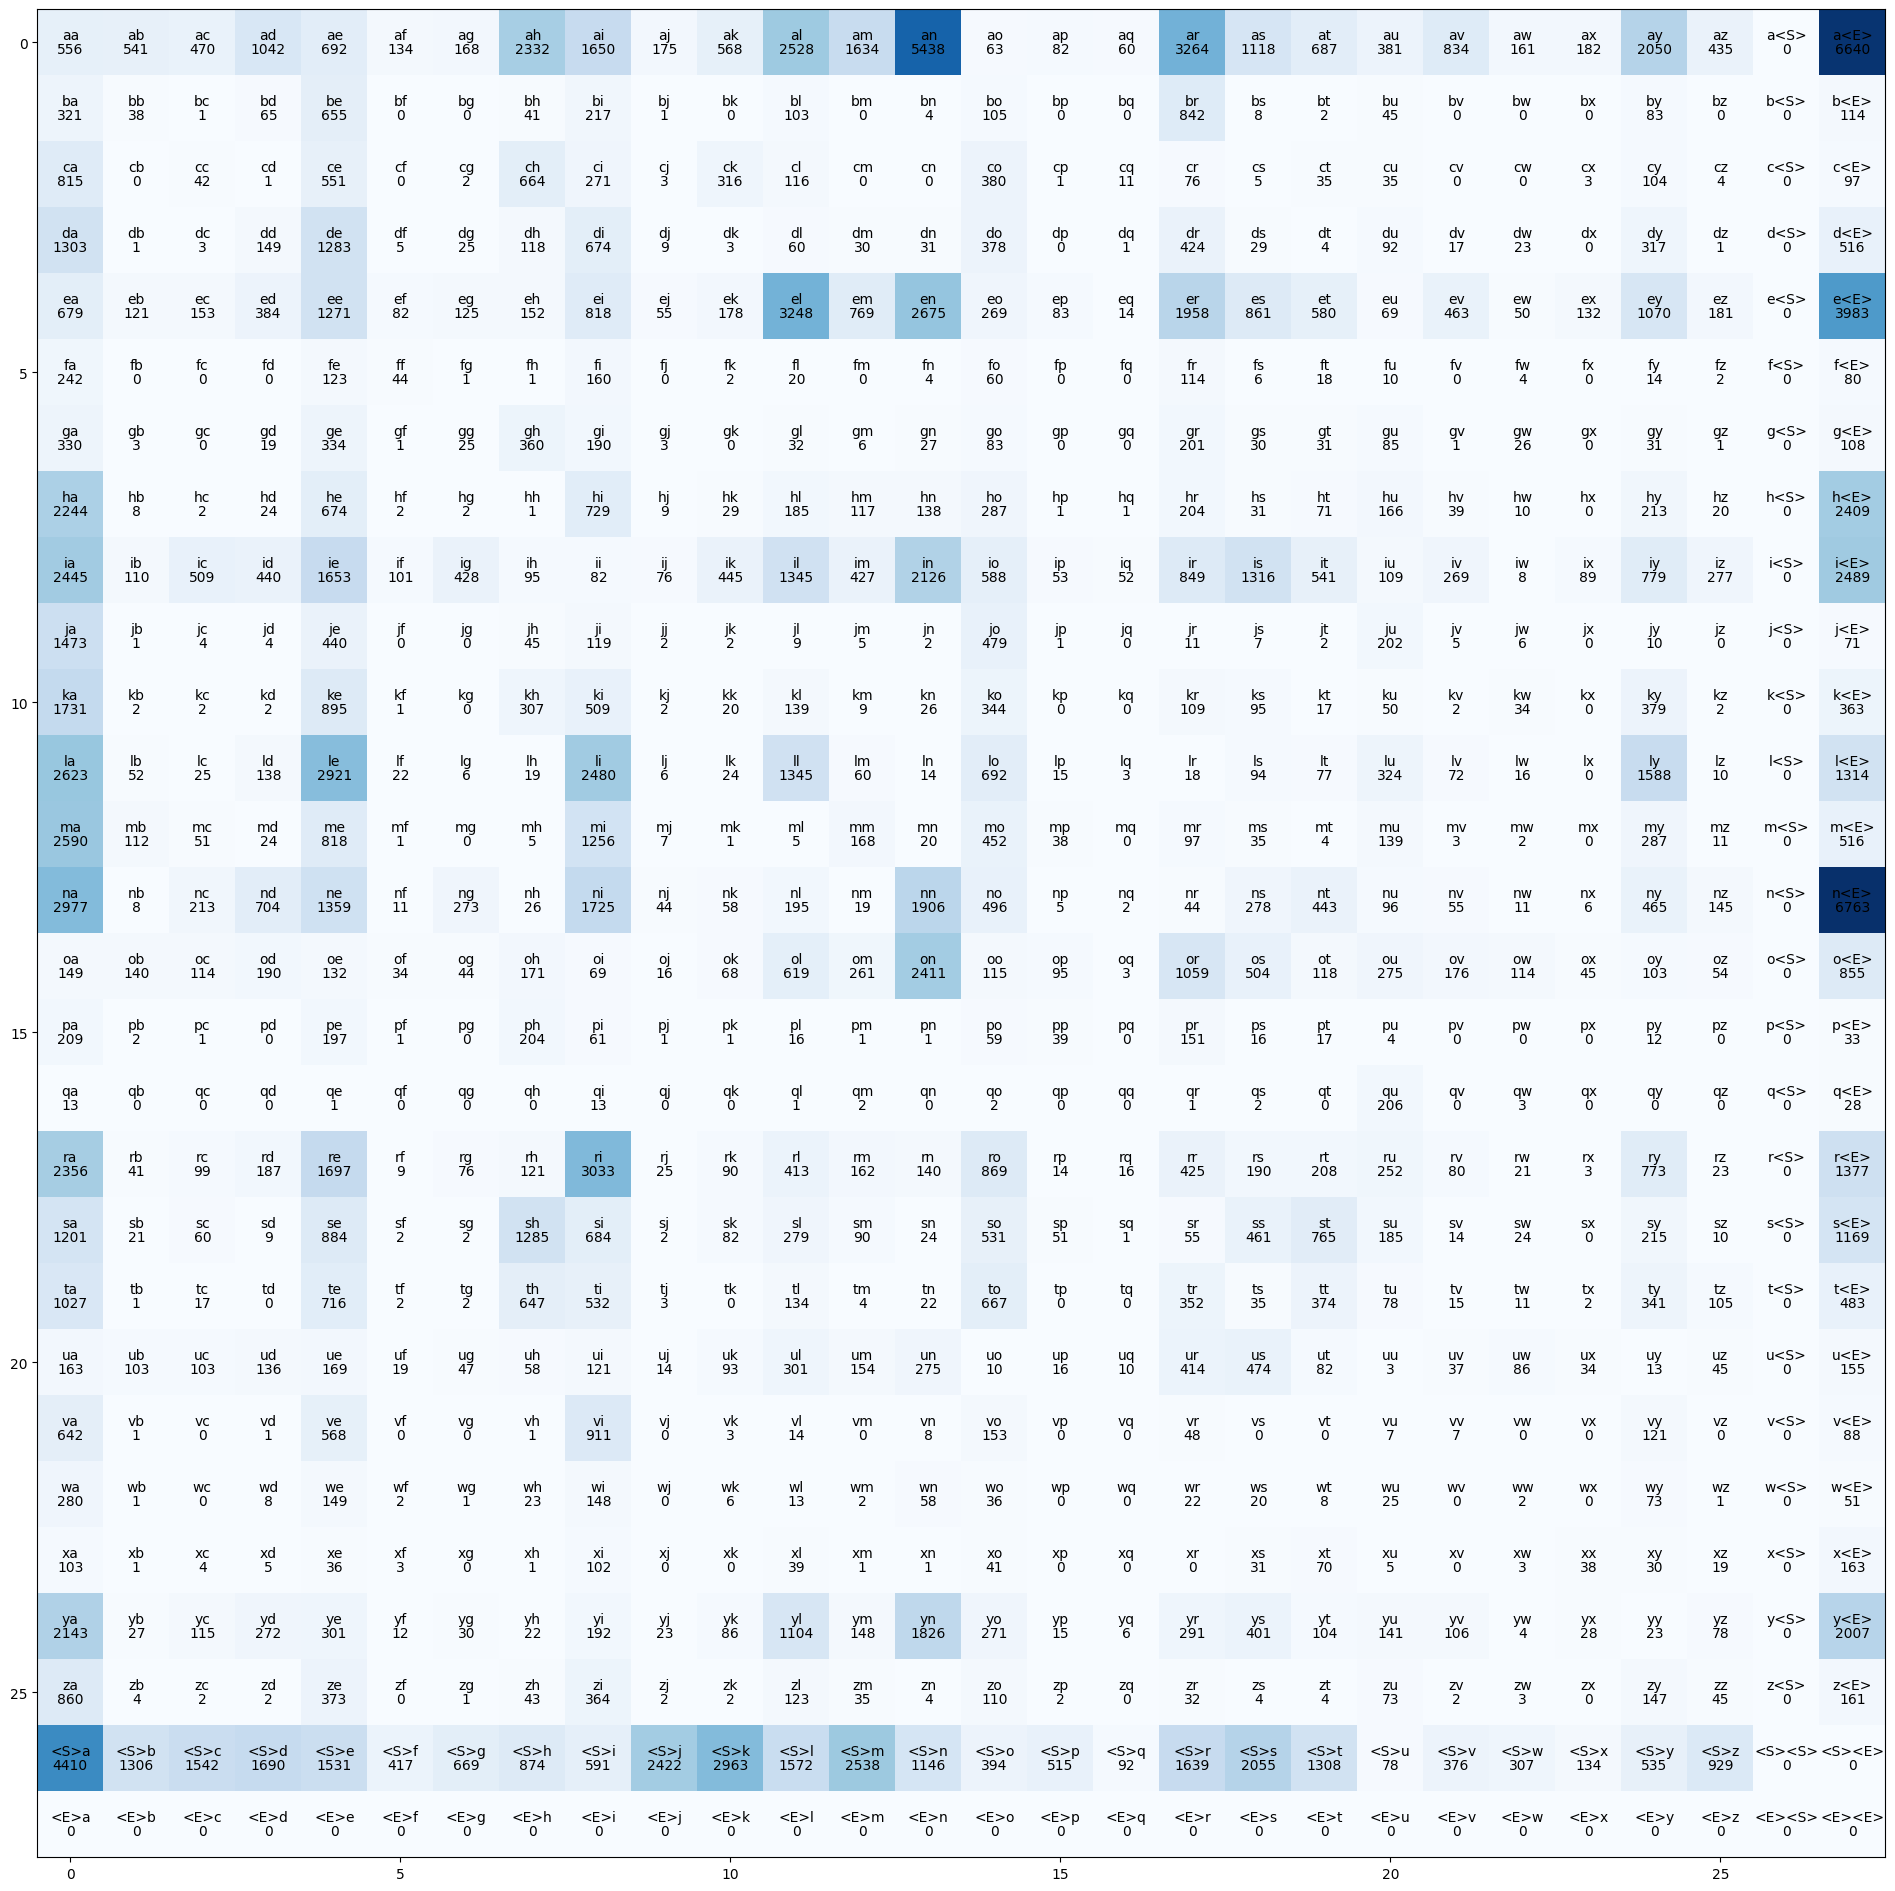

In [151]:
plt.figure(figsize=(24,24))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = idx2char[i] + idx2char[j]
        plt.text(j, i, chstr, ha='center', va='bottom')
        plt.text(j, i, N[i,j].item(), ha='center', va='top')
plt.show()

## Plot Twist:
using 'S' and 'E' special chars turns out to cause minor problems downstream. For example in the plot abpve we see there is a row of zeros because E cannot precede any char, and a column of zeros because S cannot follow another char.

solution: redefine the bigrams with a new single special token '.'

In [31]:
vocab = sorted(list(set(''.join(names))))

In [ ]:
vocab

In [32]:
N = torch.zeros((27,27), dtype=torch.int32)
N.shape

torch.Size([27, 27])

In [33]:
char2idx = {char: i+1 for i, char in enumerate(vocab)}
char2idx['.'] = 0
char2idx

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [34]:
char2idx.items()

dict_items([('a', 1), ('b', 2), ('c', 3), ('d', 4), ('e', 5), ('f', 6), ('g', 7), ('h', 8), ('i', 9), ('j', 10), ('k', 11), ('l', 12), ('m', 13), ('n', 14), ('o', 15), ('p', 16), ('q', 17), ('r', 18), ('s', 19), ('t', 20), ('u', 21), ('v', 22), ('w', 23), ('x', 24), ('y', 25), ('z', 26), ('.', 0)])

In [35]:
idx2char = {i: char for char, i in char2idx.items()}
idx2char

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [36]:
for name in names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]): # these are chars, we wanna map them to ints for lookup
        idx1 = char2idx[ch1]
        idx2 = char2idx[ch2]
        N[idx1, idx2] += 1

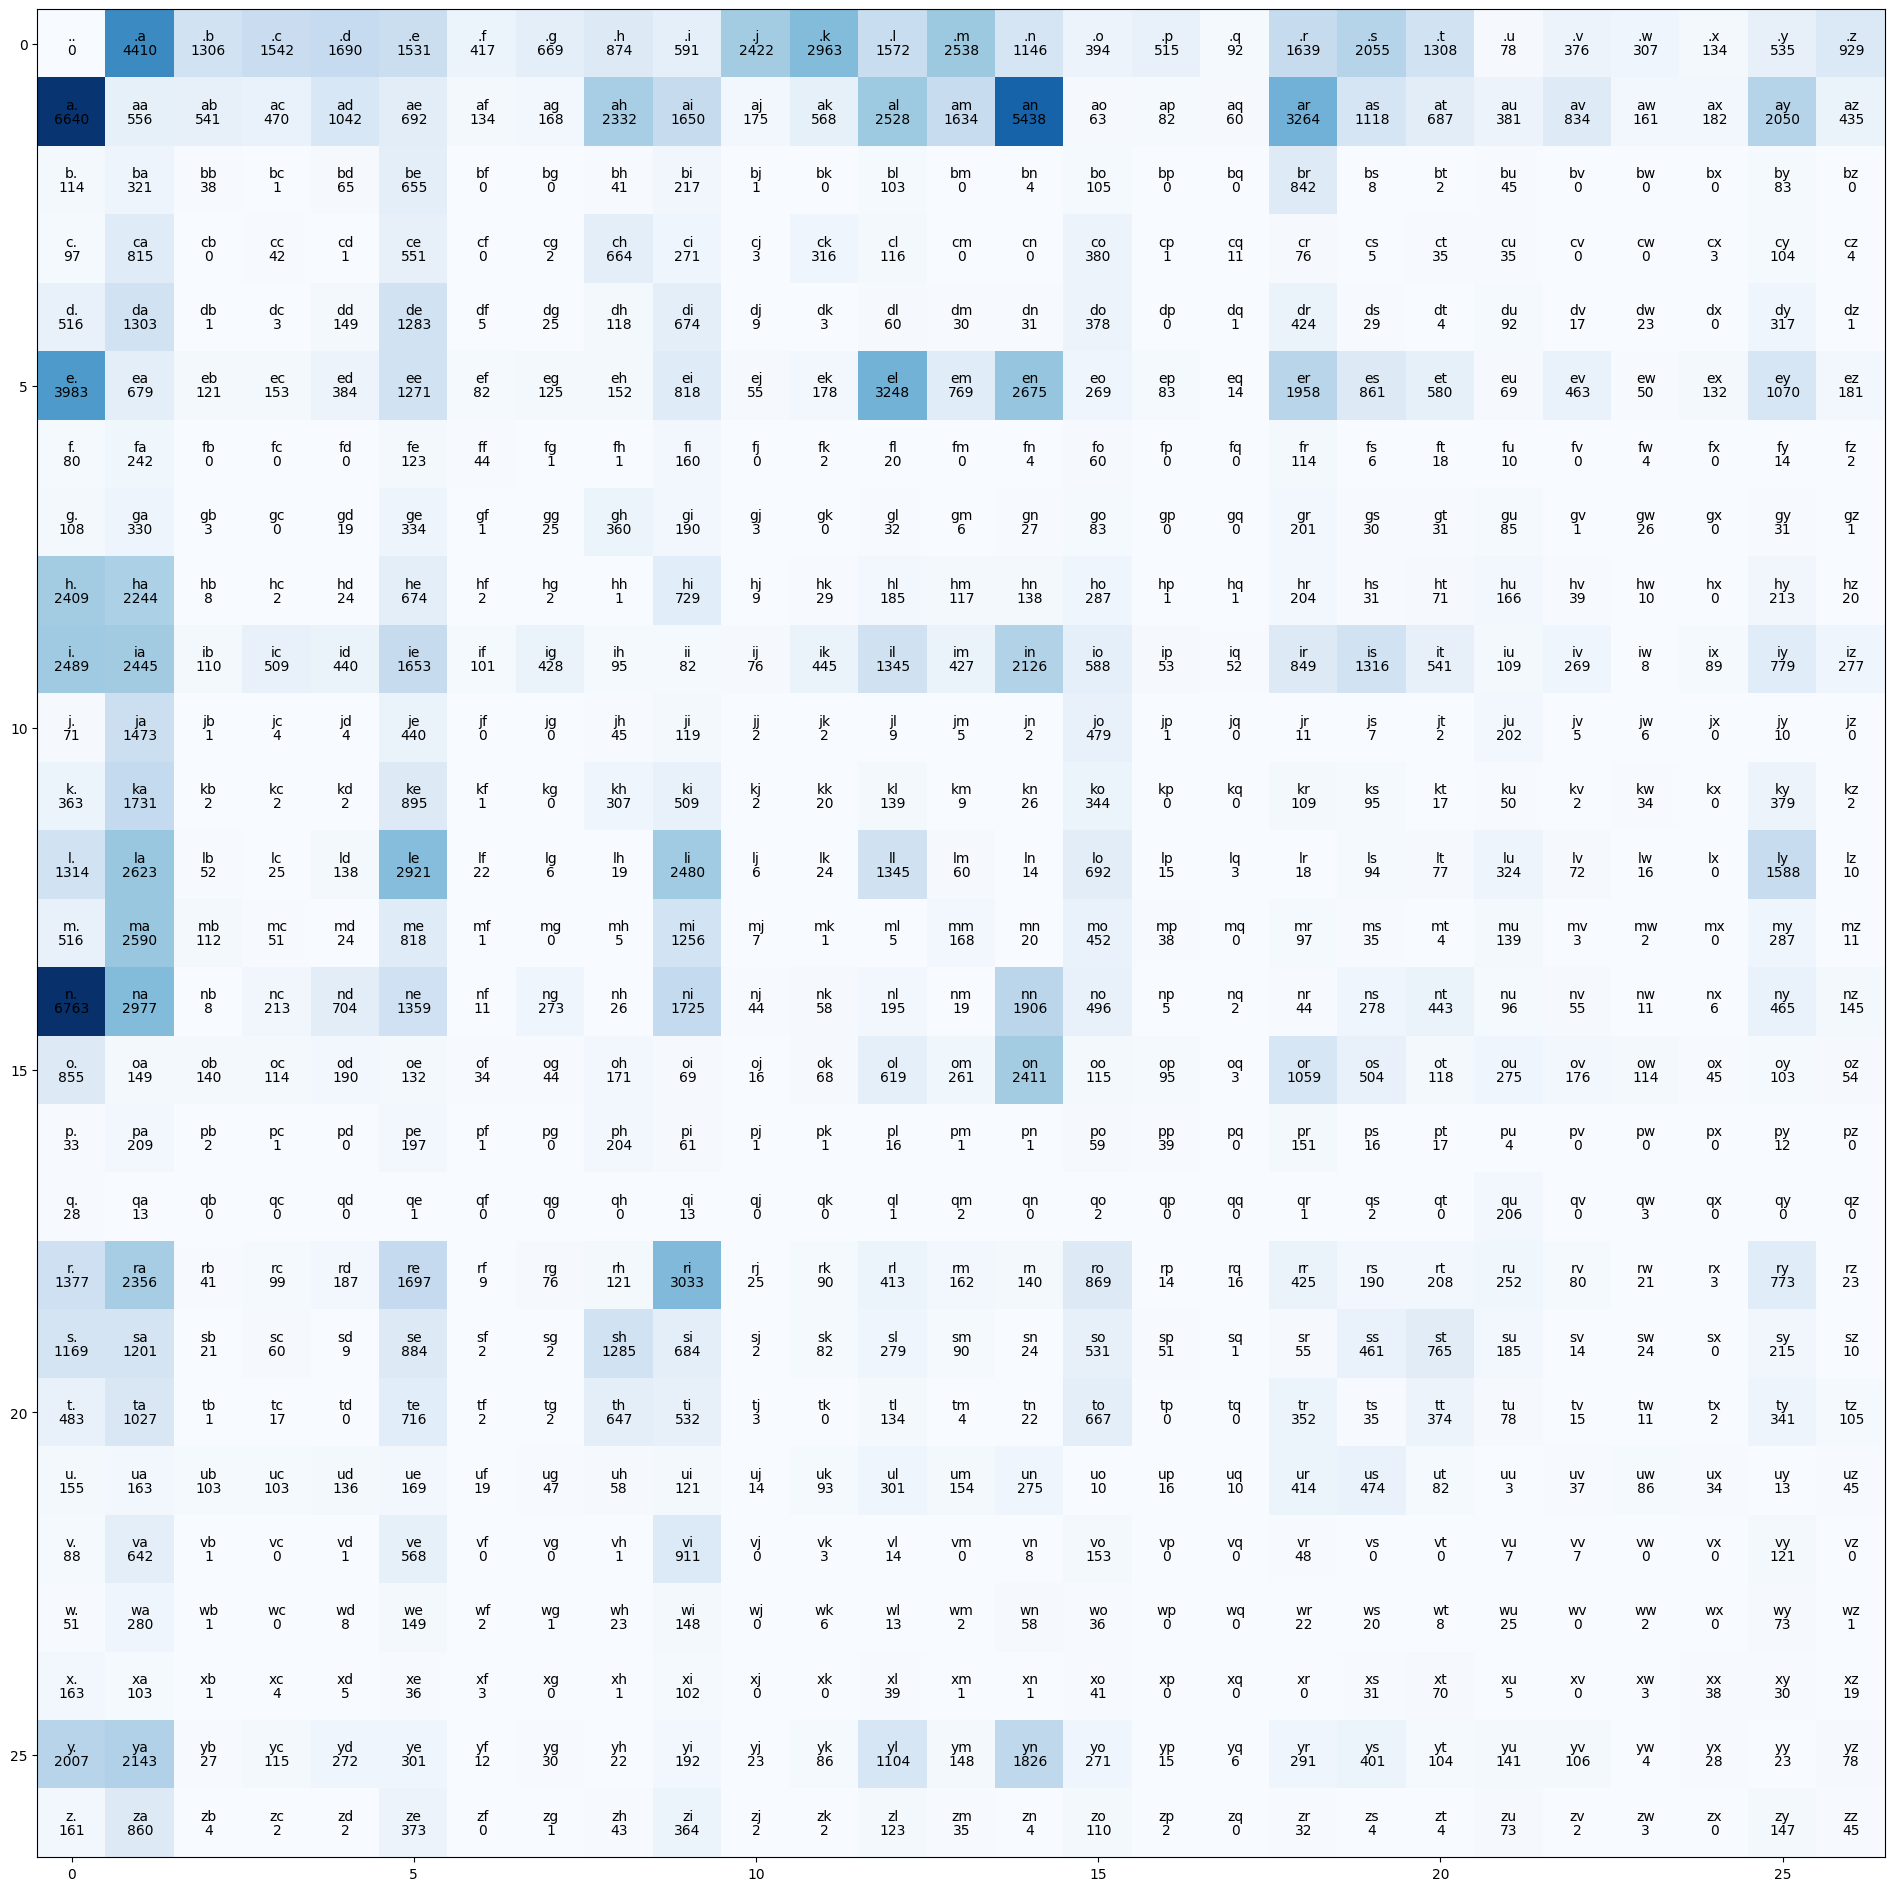

In [37]:
plt.figure(figsize=(24,24))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = idx2char[i] + idx2char[j]
        plt.text(j, i, chstr, ha='center', va='bottom')
        plt.text(j, i, N[i,j].item(), ha='center', va='top')
plt.show()

In [ ]:
N[0, :] / N[0,:].sum() 

# 13% chance of the name starting in 'a'

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [215]:
# p = N[0, :].float()
# p = p / p.sum()
# # now we wanna sample from the prob distri p
# p

In [216]:
# p.sum()

In [217]:
# # to ensure reproducibitliy, use a generator
# g = torch.Generator().manual_seed(2147483647)
# p = torch.rand(3, generator=g)
# p = p / p.sum()
# p

In [218]:
# torch.multinomial(p, num_samples=100, replacement=True, generator=g)

In [38]:
p = N[0, :].float()
p = p / p.sum()
# now we wanna sample from the prob distri p
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [39]:
g = torch.Generator().manual_seed(2147483647)
idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
idx

3

In [40]:
idx2char[idx]

'c'

In [ ]:
# loop to sample chars and generate names
# g = torch.Generator().manual_seed(2147483647)
out = []
for i in range(20):
    idx = 0 # start token 
    chars = [] # to store the chars of the name
    while True:
        p = N[idx, :].float()
        p = p / p.sum() # prob dist
        idx = torch.multinomial(p, num_samples=1, replacement=True).item()
        # print(idx2char[idx], end='')
        if idx == 0: # end token
            break
        chars.append(idx2char[idx])
    out.append(''.join(chars))
    # print(''.join(out))

In [258]:
out

['lyliaritcaveldviel',
 'keran',
 'na',
 'kaivin',
 'marylan',
 'lira',
 'ikedh',
 'a',
 'kuthrare',
 'rle',
 'ja',
 'nniemaiey',
 'edrm',
 'kaho',
 'cahe',
 'jaah',
 'lo',
 'crylianriolumelyn',
 'de',
 'le']

In [260]:
# demo: untrained model where p is uniform dist

for i in range(20):
    out = []
    idx = 0 # start token 
    # chars = [] # to store the chars of the name
    while True:
        p = torch.ones(27) / 27.0 # uniform dist
        # p = N[idx, :].float()
        # p = p / p.sum() # prob dist
        idx = torch.multinomial(p, num_samples=1, replacement=True).item()
        # print(idx2char[idx], end='')
        out.append(idx2char[idx])
        if idx == 0: # end token
            break
        # chars.append(idx2char[idx])
    # out.append(''.join(chars))
    print(''.join(out))

itbgnpemvxkmfytzfrvvhubdcrazmjgzwrlkn.
dblxqidatda.
hqhezwboalmnyricdgqrbidvyhdirzozfejwpvxkrkrqfgoaczutrphpzqohreloemojtxicypbteladhxt.
iybtugwvaemoyfnimpuxqbvbfrlxdloqpjdplqqwjsjahfwp.
ioajriklziahvtlodereqrohdoxhygzyujffpokydljcodd.
axsvgeedfzohedf.
ljlwenzvteqm.
gepzxevytztoupcsiungocstxjsacjabpsowygnvhedmlpxziwe.
caytmoiohpqkmfcduqrtypyfnyiegekjnnxerpfxd.
uhylbqepkww.
uzazwqjxkcwuehfxtdzbguzyghggtteaurzlrpokxirhtczwoxfcojlngofwnruadoyrgufj.
vawdtbowfyynvbkhufv.
wpkgrgeodxobsfaktn.
ipweacijhxighcqcjomlttfixsbabkorbbytjxbtauxbwvlhozsklikqpuhqrhgvrouwlwcukkchezarbipzvbfoh.
gldftboqpgbrpdrgudgektkkzwwrvtuspfrtwfklnpnjgrdppl.
gssshhszqmvzm.
yohhfcecayknjgdqmvru.
rbjsqxurbdvnuhvwfpihfufaeobebkn.
aanuhqika.
okmjqgvjonafmhhijslotoujcsqv.


## fixing up some inefficiencies in the code
`p = N[idx, :].float()
`p = p / p.sum() # prob dist

these 2 line cause a bottleneck because we need to extract and cast and scale for each iter

### Broadcasting and keepdim arg:

#### Rules of Broadcasting in torch
- aligh dims to the write
- dims have to be:
    - equal
    - one of them equal to 1
    - one does not exist

Two tensors are “broadcastable” if the following rules hold:

When iterating over the dimension sizes, starting at the trailing dimension, the dimension sizes must either be equal, one of them is 1, or one of them does not exist.
```python
x=torch.empty(5,7,3)
y=torch.empty(5,7,3)
# same shapes are always broadcastable (i.e. the above rules always hold)

x=torch.empty((0,))
y=torch.empty(2,2)
# x and y are not broadcastable, because the 0-sized dimension of x
# does not match the 2-sized dimension of y.

x=torch.empty(5,3,4,1)
y=torch.empty(  3,1,1)
# x and y are broadcastable.
# 1st trailing dimension: both have size 1
# 2nd trailing dimension: y has size 1
# 3rd trailing dimension: x size == y size
# 4th trailing dimension: y dimension doesn't exist

x=torch.empty(5,2,4,1)
y=torch.empty(  3,1,1)
# x and y are not broadcastable, because in the 3rd trailing dimension 2 != 3
```

If two tensors x, y are “broadcastable”, the resulting tensor size is calculated as follows:

If the number of dimensions of x and y are not equal, prepend 1 to the dimensions of the tensor with fewer dimensions to make them equal length.

Then, for each dimension size, the resulting dimension size is the max of the sizes of x and y along that dimension.

For Example:

```python
# can line up trailing dimensions to make reading easier
>>> x=torch.empty(5,1,4,1)
>>> y=torch.empty(  3,1,1)
>>> (x+y).size()
torch.Size([5, 3, 4, 1])

# but not necessary:
>>> x=torch.empty(1)
>>> y=torch.empty(3,1,7)
>>> (x+y).size()
torch.Size([3, 1, 7])

>>> x=torch.empty(5,2,4,1)
>>> y=torch.empty(3,1,1)
>>> (x+y).size()
RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 1
```

In [280]:
# P = N.float() 
# P.sum() # sum of all counts
# P.sum(dim=0, keepdim=True).shape # row vector
# P.sum(dim=1, keepdim=True).shape # col vector

In [ ]:
# not using keepdim=True here will cause a very subtle bug
# P = N.float()
# P = P / P.sum(dim=1) --> shape will be (27,) instead of (27,1) 
# and the broadcasting will be wrong when we do the row normalization

# 27,   27 --> P
#       27 --> P.sum(dim=1).shape
# 27,   27 --> shape of the result of the operation
# broadcasting will be wrong if we don't use keepdim=True 
# because the shape of the divisor will be (27,) instead of (27,1) 
# and it will divide each column by the corresponding row sum 
# instead of dividing each row by its own sum.

In [ ]:
#operation is broadcastable
# 27,   27 --> P
# 27,    1 --> P.sum(dim=1, keepdim=True).shape
# 27,   27 --> shape of the result of the operation


# broadcasting rules:
# align dims to the right
# dims have to be either
### equal
### if not equal one of them has to be 1
### or dim does not exist

In [41]:
# matrix of probs
P = N.float() 
P = P / P.sum(dim=1, keepdim=True)

In [43]:
P.shape

torch.Size([27, 27])

In [44]:
P.sum(dim=1) # sanity check - all probs add up to 1 in a single row

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [45]:
# loop to sample chars and generate names
g = torch.Generator().manual_seed(2147483647)
out = []
for i in range(20):
    idx = 0 # start token 
    chars = [] # to store the chars of the name
    while True:
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        p = P[idx]
        if idx == 0: # end token
            break
        chars.append(idx2char[idx])
    out.append(''.join(chars))

In [46]:
out

['cexze',
 'momasurailezitynn',
 'konimittain',
 'llayn',
 'ka',
 'da',
 'staiyaubrtthrigotai',
 'moliellavo',
 'ke',
 'teda',
 'ka',
 'emimmsade',
 'enkaviyny',
 'ftlspihinivenvorhlasu',
 'dsor',
 'br',
 'jol',
 'pen',
 'aisan',
 'ja']

### Model Eval - Loss function

In [292]:
log_likelihoods = 0.0
n = 0
for name in names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = char2idx[ch1]
        idx2 = char2idx[ch2]
        prob = P[idx1, idx2].item()
        logprob = torch.log(P[idx1, idx2]).item()
        log_likelihoods += logprob # we actually want the avg later on
        n += 1
        # print(f'{ch1}{ch2}: {prob:.4f} ({logprob:.4f})')
print(f'Log likelihood: {log_likelihoods:.4f}')
print(f'Average log likelihood: {log_likelihoods / n:.4f}')
neg_log_likelihood = -log_likelihoods
print(f'Negative log likelihood: {neg_log_likelihood:.4f}')
print(f'Average negative log likelihood: {neg_log_likelihood / n:.4f}')

Log likelihood: -559866.0639
Average log likelihood: -2.4540
Negative log likelihood: 559866.0639
Average negative log likelihood: 2.4540


In [ ]:
# Average negative log likelihood: 2.4540
# this is the loss we wanna get to (or better) in the MLP approach

In [284]:
# important
# we have 27 possible tokens
# if we sample the next token completely randomly
# each token has a 1/27 chance of being selected
# so anything above 4% in the probs means we lean]rned sth
1/27.

0.037037037037037035

In [ ]:
# how can we use these probs to eval our model?
# we can use the likelihood, which is the product of all these probs,
# the problem with the likelihood is that it can be very small, so we can use 
# the log likelihood instead, which is the sum of the log probs
# log is a monotonic function, so it does not change the order of the probs, 
# but it makes it easier to work with small numbers and to compute gradients for optimization.
# log likelihood is the sum of the log probs of the bigrams in the name

In [295]:
log_likelihoods = 0.0
n = 0
for name in ['abdallahqx']:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = char2idx[ch1]
        idx2 = char2idx[ch2]
        prob = P[idx1, idx2].item()
        logprob = torch.log(P[idx1, idx2]).item()
        log_likelihoods += logprob # we actually want the avg later on
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} ({logprob:.4f})')
print(f'Log likelihood: {log_likelihoods:.4f}')
print(f'Average log likelihood: {log_likelihoods / n:.4f}')
neg_log_likelihood = -log_likelihoods
print(f'Negative log likelihood: {neg_log_likelihood:.4f}')
print(f'Average negative log likelihood: {neg_log_likelihood / n:.4f}')

.a: 0.1377 (-1.9829)
ab: 0.0160 (-4.1373)
bd: 0.0246 (-3.7060)
da: 0.2371 (-1.4394)
al: 0.0746 (-2.5955)
ll: 0.0964 (-2.3397)
la: 0.1879 (-1.6717)
ah: 0.0688 (-2.6762)
hq: 0.0001 (-8.9380)
qx: 0.0000 (-inf)
x.: 0.2342 (-1.4516)
Log likelihood: -inf
Average log likelihood: -inf
Negative log likelihood: inf
Average negative log likelihood: inf


In [296]:
# model smoothing
# matrix of probs
P = (N+1).float() 
P = P / P.sum(dim=1, keepdim=True)


log_likelihoods = 0.0
n = 0
for name in ['abdallahqx']:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = char2idx[ch1]
        idx2 = char2idx[ch2]
        prob = P[idx1, idx2].item()
        logprob = torch.log(P[idx1, idx2]).item()
        log_likelihoods += logprob # we actually want the avg later on
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} ({logprob:.4f})')
print(f'Log likelihood: {log_likelihoods:.4f}')
print(f'Average log likelihood: {log_likelihoods / n:.4f}')
neg_log_likelihood = -log_likelihoods
print(f'Negative log likelihood: {neg_log_likelihood:.4f}')
print(f'Average negative log likelihood: {neg_log_likelihood / n:.4f}')

.a: 0.1376 (-1.9835)
ab: 0.0160 (-4.1363)
bd: 0.0247 (-3.7009)
da: 0.2361 (-1.4435)
al: 0.0746 (-2.5959)
ll: 0.0962 (-2.3408)
la: 0.1876 (-1.6733)
ah: 0.0688 (-2.6766)
hq: 0.0003 (-8.2484)
qx: 0.0033 (-5.7004)
x.: 0.2268 (-1.4835)
Log likelihood: -35.9833
Average log likelihood: -3.2712
Negative log likelihood: 35.9833
Average negative log likelihood: 3.2712
